In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

import nltk
from nltk.tokenize import RegexpTokenizer
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from imblearn.under_sampling import RandomUnderSampler
from sklearn.naive_bayes import MultinomialNB
from sklearn import metrics

from collections import Counter
from wordcloud import WordCloud
from nltk.sentiment.vader import SentimentIntensityAnalyzer

In [27]:
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('vader_lexicon')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [2]:
### 4-10) Pre-processing exploration on a simple example
# 4) Simple example text
simple_text = "This isn't a real text, this is an example text...Notice this contains punctuation!!"

# 5) Tokenization (keep apostrophes, remove other punctuation)
tokenizer = RegexpTokenizer(r"[a-zA-Z0-9]+'?[a-zA-Z0-9]+|[a-zA-Z0-9]+")
tokenized_document = tokenizer.tokenize(simple_text.lower())
print(tokenized_document)

['this', "isn't", 'a', 'real', 'text', 'this', 'is', 'an', 'example', 'text', 'notice', 'this', 'contains', 'punctuation']


In [3]:
# 6) Load stopwords
stop_words = nltk.corpus.stopwords.words('english')
print(stop_words[:20])

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been']


In [4]:
# 7) Remove stopwords (using list comprehension)
cleaned_tokens = [word.lower() for word in tokenized_document if word.lower() not in stop_words]
print(cleaned_tokens)

['real', 'text', 'example', 'text', 'notice', 'contains', 'punctuation']


In [5]:
# 8) Stemming vs Lemmatization demo
lemmatizer = nltk.stem.WordNetLemmatizer()
stemmer = nltk.stem.PorterStemmer()

words = ['cacti','sings','hopped','rocks','better','easily']
pos = ['n','v','v','n','a','r']

lemmatized_words = [lemmatizer.lemmatize(words[i], pos=pos[i]) for i in range(6)]
stemmed_words = [stemmer.stem(word) for word in words]

print("Lemmatized words:", lemmatized_words)
print("Stemmed words   :", stemmed_words)

Lemmatized words: ['cactus', 'sing', 'hop', 'rock', 'good', 'easily']
Stemmed words   : ['cacti', 'sing', 'hop', 'rock', 'better', 'easili']


In [6]:
# 9) Apply stemming to our example
stemmed_text = [stemmer.stem(word) for word in cleaned_tokens]
print(stemmed_text)

['real', 'text', 'exampl', 'text', 'notic', 'contain', 'punctuat']


In [7]:
# 10) Define full preprocessing function
def preprocess_text(text):
    tokenizer = RegexpTokenizer(r"[a-zA-Z0-9]+'?[a-zA-Z0-9]+|[a-zA-Z0-9]+")
    tokens = tokenizer.tokenize(text.lower())
    stop_words = set(stopwords.words('english'))
    cleaned_tokens = [word for word in tokens if word not in stop_words]
    stemmed = [PorterStemmer().stem(word) for word in cleaned_tokens]
    return stemmed

# Test the function
print(preprocess_text(simple_text))

['real', 'text', 'exampl', 'text', 'notic', 'contain', 'punctuat']


In [8]:
# 11) Read SMS data (tab-separated, no header)
data = pd.read_csv('/content/SMSSpamCollection.txt', sep='\t', header=None)
data.columns = ['Target_Label', 'Text']
data.head()

,Target_Label,Text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [9]:
# 12) Check class distribution
print("Class distribution:")
print(data.groupby('Target_Label').count())

Class distribution:
              Text
Target_Label      
ham           4825
spam           747


In [10]:
# 12) Check class distribution
print("Class distribution:")
print(data.groupby('Target_Label').count())

Class distribution:
              Text
Target_Label      
ham           4825
spam           747


In [11]:
data['Text'] = data['Text'].apply(preprocess_text)
data.head()

,Target_Label,Text
0,ham,"[go, jurong, point, crazi, avail, bugi, n, gre..."
1,ham,"[ok, lar, joke, wif, u, oni]"
2,spam,"[free, entri, 2, wkli, comp, win, fa, cup, fin..."
3,ham,"[u, dun, say, earli, hor, u, c, alreadi, say]"
4,ham,"[nah, think, goe, usf, live, around, though]"


In [12]:
# Join tokens back into strings for CountVectorizer
data['Text_joined'] = data['Text'].apply(' '.join)

vectorizer = CountVectorizer()
X = vectorizer.fit_transform(data['Text_joined'])
X_df = pd.DataFrame(X.toarray())
X_df.head()

,0,1,2,3,4,5,6,7,8,9,...,7264,7265,7266,7267,7268,7269,7270,7271,7272,7273
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


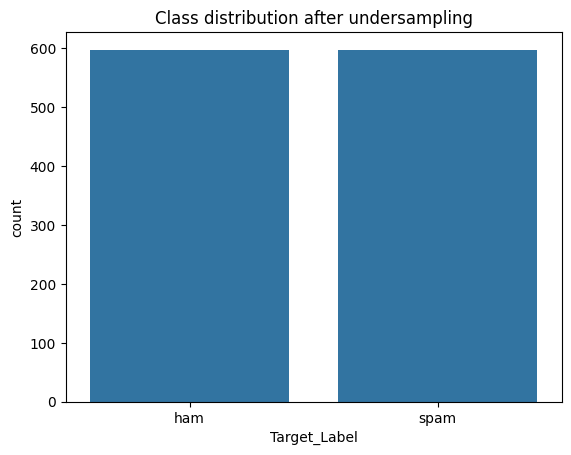

In [13]:
y = data['Target_Label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=99, stratify=y)

# Undersample the majority class (ham)
rus = RandomUnderSampler(random_state=0)
X_train_undersampled, y_train_undersampled = rus.fit_resample(X_train, y_train)

# Plot class distribution after undersampling
sns.countplot(x=y_train_undersampled)
plt.title("Class distribution after undersampling")
plt.show()

In [14]:
model = MultinomialNB()
model.fit(X_train_undersampled, y_train_undersampled)
print("Model trained!")

Model trained!


In [15]:
y_pred = model.predict(X_test)

print("Accuracy: {:.2f}%".format(metrics.accuracy_score(y_test, y_pred)*100))
print("\nConfusion Matrix:")
print(metrics.confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(metrics.classification_report(y_test, y_pred))

Accuracy: 94.26%

Confusion Matrix:
[[907  59]
 [  5 144]]

Classification Report:
              precision    recall  f1-score   support

         ham       0.99      0.94      0.97       966
        spam       0.71      0.97      0.82       149

    accuracy                           0.94      1115
   macro avg       0.85      0.95      0.89      1115
weighted avg       0.96      0.94      0.95      1115



In [16]:
# 18) Load Amazon reviews
reviews = pd.read_csv('Reviews_of_Amazon_Products.csv')
reviews.head()

,Category,name,brand,primaryCategories,reviews.date,reviews.text,reviews.title,reviews.username
0,Kindle,"Amazon Kindle E-Reader 6"" Wifi (8th Generation...",Amazon,Electronics,2017-09-03T00:00:00.000Z,I thought it would be as big as small paper bu...,Too small,llyyue
1,Kindle,"Amazon Kindle E-Reader 6"" Wifi (8th Generation...",Amazon,Electronics,2017-06-06T00:00:00.000Z,This kindle is light and easy to use especiall...,Great light reader. Easy to use at the beach,Charmi
2,Kindle,"Amazon Kindle E-Reader 6"" Wifi (8th Generation...",Amazon,Electronics,2018-04-20T00:00:00.000Z,Didnt know how much i'd use a kindle so went f...,Great for the price,johnnyjojojo
3,Kindle,"Amazon Kindle E-Reader 6"" Wifi (8th Generation...",Amazon,Electronics,2017-11-02T17:33:31.000Z,I am 100 happy with my purchase. I caught it o...,A Great Buy,Kdperry
4,Kindle,"Amazon Kindle E-Reader 6"" Wifi (8th Generation...",Amazon,Electronics,2018-04-24T00:00:00.000Z,Solid entry level Kindle. Great for kids. Gift...,Solid entry-level Kindle. Great for kids,Johnnyblack


In [17]:
# 19) Summary statistics
reviews.describe()

,Category,name,brand,primaryCategories,reviews.date,reviews.text,reviews.title,reviews.username
count,1123,1123,1123,1123,1123,1123,1123,1123
unique,2,7,1,2,237,1048,820,983
top,Tablet,"Fire HD 8 Tablet, Wi-Fi, 16 GB-Magenta",Amazon,Electronics,2017-01-06T00:00:00.000Z,Good tablet. Gave as gift and person enjoys it...,Great tablet,John
freq,1016,797,1123,1112,48,3,56,5


In [18]:
# 20) Initialize VADER sentiment analyzer
sentiment = SentimentIntensityAnalyzer()

# Apply VADER to each review (using raw text, not preprocessed)
review_text = reviews['reviews.text'].astype(str)

# Create new columns from the sentiment scores
reviews['neg'] = review_text.apply(lambda x: sentiment.polarity_scores(x)['neg'])
reviews['neu'] = review_text.apply(lambda x: sentiment.polarity_scores(x)['neu'])
reviews['pos'] = review_text.apply(lambda x: sentiment.polarity_scores(x)['pos'])
reviews['compound'] = review_text.apply(lambda x: sentiment.polarity_scores(x)['compound'])

reviews[['name', 'reviews.text', 'neg', 'neu', 'pos', 'compound']].head()

,name,reviews.text,neg,neu,pos,compound
0,"Amazon Kindle E-Reader 6"" Wifi (8th Generation...",I thought it would be as big as small paper bu...,0.081,0.709,0.210,0.7329
1,"Amazon Kindle E-Reader 6"" Wifi (8th Generation...",This kindle is light and easy to use especiall...,0.000,0.744,0.256,0.5826
2,"Amazon Kindle E-Reader 6"" Wifi (8th Generation...",Didnt know how much i'd use a kindle so went f...,0.085,0.772,0.143,0.3612
3,"Amazon Kindle E-Reader 6"" Wifi (8th Generation...",I am 100 happy with my purchase. I caught it o...,0.000,0.843,0.157,0.9727
4,"Amazon Kindle E-Reader 6"" Wifi (8th Generation...",Solid entry level Kindle. Great for kids. Gift...,0.000,0.661,0.339,0.9072


In [19]:
# 21) Inspect results
reviews.head()

,Category,name,brand,primaryCategories,reviews.date,reviews.text,reviews.title,reviews.username,neg,neu,pos,compound
0,Kindle,"Amazon Kindle E-Reader 6"" Wifi (8th Generation...",Amazon,Electronics,2017-09-03T00:00:00.000Z,I thought it would be as big as small paper bu...,Too small,llyyue,0.081,0.709,0.210,0.7329
1,Kindle,"Amazon Kindle E-Reader 6"" Wifi (8th Generation...",Amazon,Electronics,2017-06-06T00:00:00.000Z,This kindle is light and easy to use especiall...,Great light reader. Easy to use at the beach,Charmi,0.000,0.744,0.256,0.5826
2,Kindle,"Amazon Kindle E-Reader 6"" Wifi (8th Generation...",Amazon,Electronics,2018-04-20T00:00:00.000Z,Didnt know how much i'd use a kindle so went f...,Great for the price,johnnyjojojo,0.085,0.772,0.143,0.3612
3,Kindle,"Amazon Kindle E-Reader 6"" Wifi (8th Generation...",Amazon,Electronics,2017-11-02T17:33:31.000Z,I am 100 happy with my purchase. I caught it o...,A Great Buy,Kdperry,0.000,0.843,0.157,0.9727
4,Kindle,"Amazon Kindle E-Reader 6"" Wifi (8th Generation...",Amazon,Electronics,2018-04-24T00:00:00.000Z,Solid entry level Kindle. Great for kids. Gift...,Solid entry-level Kindle. Great for kids,Johnnyblack,0.000,0.661,0.339,0.9072


In [20]:
# 22) Describe sentiment scores
reviews[['neg','neu','pos','compound']].describe()

,neg,neu,pos,compound
count,1123.000000,1123.000000,1123.000000,1123.000000
mean,0.033545,0.694907,0.271563,0.623324
std,0.058432,0.147549,0.152466,0.347236
min,0.000000,0.230000,0.000000,-0.867400
25%,0.000000,0.592000,0.163000,0.493900
50%,0.000000,0.705000,0.259000,0.750600
75%,0.055500,0.800500,0.380000,0.865800
max,0.475000,1.000000,0.689000,0.999200


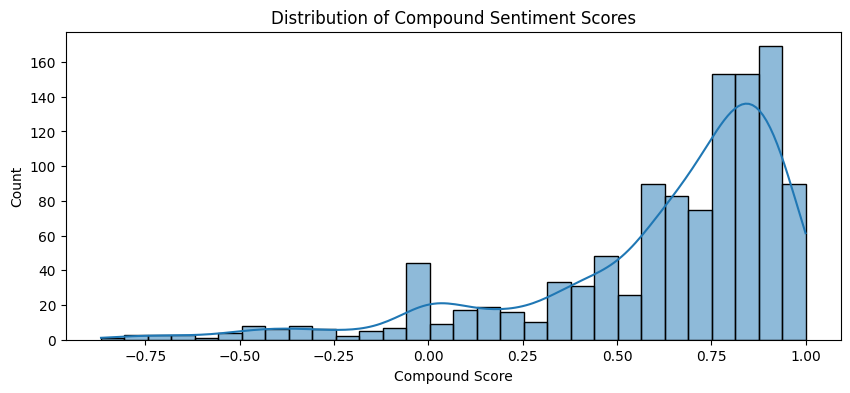

In [21]:
# 23) Distribution of compound scores
plt.figure(figsize=(10,4))
sns.histplot(reviews['compound'], bins=30, kde=True)
plt.title('Distribution of Compound Sentiment Scores')
plt.xlabel('Compound Score')
plt.show()

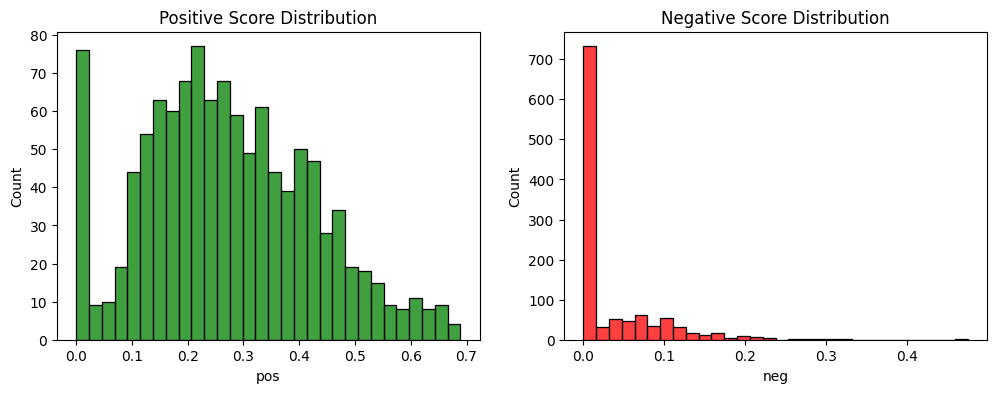

In [22]:
# Distribution of positive and negative scores
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
sns.histplot(reviews['pos'], bins=30, color='green')
plt.title('Positive Score Distribution')

plt.subplot(1,2,2)
sns.histplot(reviews['neg'], bins=30, color='red')
plt.title('Negative Score Distribution')
plt.show()

In [23]:
# 24) Negative reviews per product
reviews['is_negative'] = reviews['compound'] <= 0
negative_counts = reviews.groupby('name')['is_negative'].sum().sort_values(ascending=False)
negative_counts

,is_negative
name,
"Fire HD 8 Tablet, Wi-Fi, 16 GB-Magenta",67
"Amazon Kindle E-Reader 6"" Wifi (8th Generation, 2016)",12
"Fire HD 8 Tablet, Wi-Fi, 32 GB-Blue",10
"Fire HD 8 Tablet, Wi-Fi, 32 GB-Black",5
"Fire HD 8 Tablet, Wi-Fi, 32 GB-Magenta",5
"Fire HD 8 Tablet, Wi-Fi, 16 GB-Blue",1
"Kindle E-reader - White, 6 Glare-Free Touchscreen Display, Wi-Fi - Includes Special Offers",1


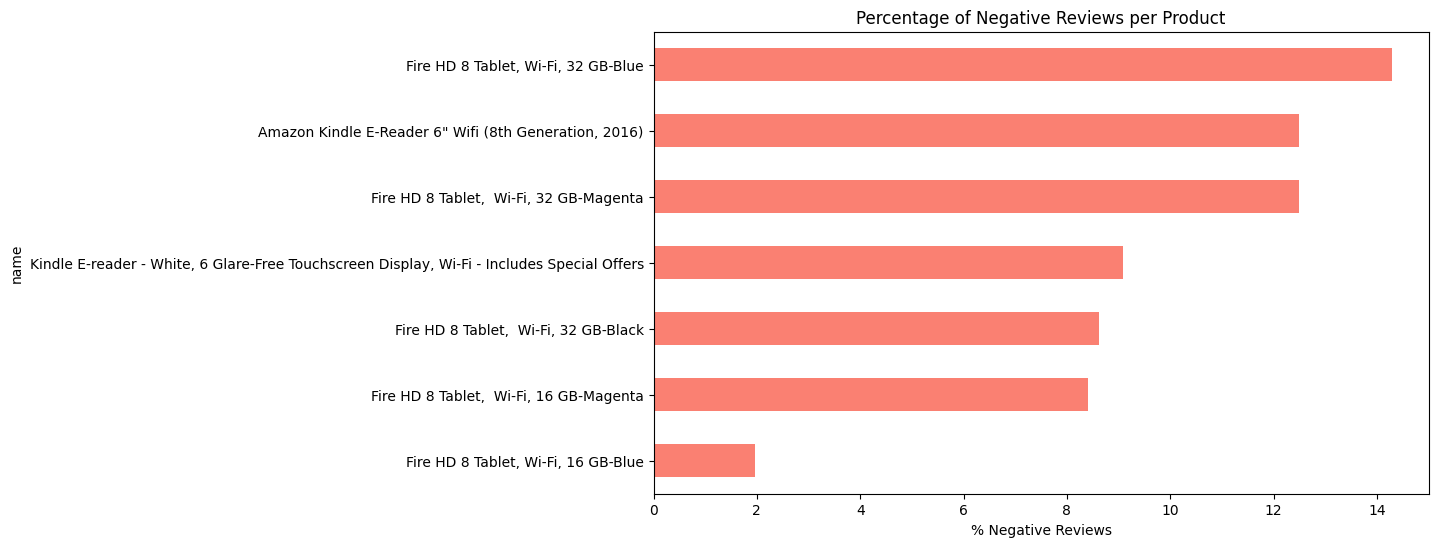

In [24]:
# 25) Proportion of negative reviews per product
total_reviews = reviews['name'].value_counts()
prop_negative = (reviews.groupby('name')['is_negative'].mean() * 100).sort_values()

plt.figure(figsize=(10,6))
prop_negative.plot(kind='barh', color='salmon')
plt.title('Percentage of Negative Reviews per Product')
plt.xlabel('% Negative Reviews')
plt.show()

In [30]:
stop_words = set(stopwords.words('english'))

# Function to extract words
def extract_words(text):
    tokens = nltk.word_tokenize(text.lower())
    words = [w for w in tokens if w.isalpha() and w not in stop_words]
    return words

reviews['clean_words'] = review_text.apply(extract_words)

sid = SentimentIntensityAnalyzer()

positive_words = []
negative_words = []

for text in reviews['reviews.text'].astype(str):
    for word in extract_words(text):
        score = sid.polarity_scores(word)['compound']
        if score >= 0.4:
            positive_words.append(word)
        elif score <= -0.4:
            negative_words.append(word)

# Count most common
pos_counts = Counter(positive_words).most_common(20)
neg_counts = Counter(negative_words).most_common(20)

print("\nTop Positive Words:\n", pos_counts)
print("\nTop Negative Words:\n", neg_counts)


Top Positive Words:
 [('great', 385), ('easy', 204), ('good', 201), ('love', 195), ('loves', 105), ('gift', 81), ('better', 74), ('perfect', 74), ('best', 65), ('nice', 62), ('happy', 44), ('excellent', 28), ('awesome', 28), ('free', 26), ('loved', 25), ('pretty', 24), ('enjoy', 23), ('amazing', 22), ('easier', 21), ('definitely', 18)]

Top Negative Words:
 [('problem', 18), ('problems', 11), ('bad', 10), ('complaints', 8), ('disappointed', 7), ('wrong', 7), ('broke', 5), ('hate', 4), ('disappointing', 4), ('annoying', 4), ('worse', 4), ('negative', 4), ('terrible', 3), ('broken', 3), ('trouble', 3), ('died', 3), ('jealous', 2), ('defective', 2), ('damaged', 2), ('worry', 2)]


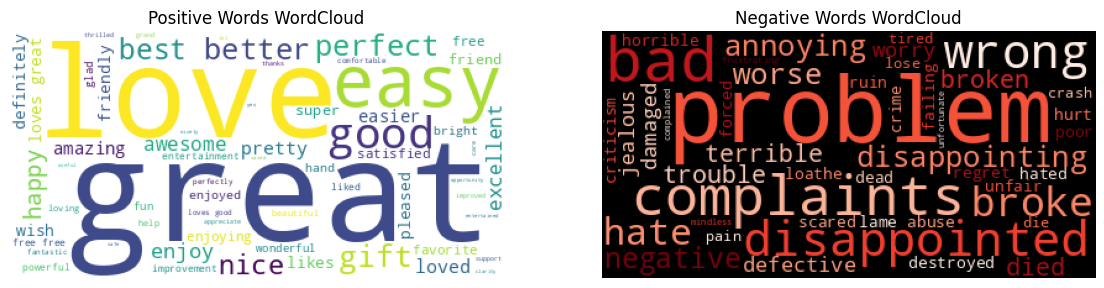

In [31]:
plt.figure(figsize=(14,6))

plt.subplot(1,2,1)
wc_pos = WordCloud(background_color='white').generate(' '.join(positive_words))
plt.imshow(wc_pos)
plt.title("Positive Words WordCloud")
plt.axis('off')

plt.subplot(1,2,2)
wc_neg = WordCloud(background_color='black', colormap='Reds').generate(' '.join(negative_words))
plt.imshow(wc_neg)
plt.title("Negative Words WordCloud")
plt.axis('off')

plt.show()

In [32]:
print("\nMost Positive Reviews:")
display(reviews.sort_values('compound', ascending=False)[['name','reviews.text','compound']].head(5))

print("\nMost Negative Reviews:")
display(reviews.sort_values('compound', ascending=True)[['name','reviews.text','compound']].head(5))


Most Positive Reviews:


,name,reviews.text,compound
1095,"Fire HD 8 Tablet, Wi-Fi, 32 GB-Magenta","I've had lots of tablets in the past, mostly f...",0.9992
181,"Fire HD 8 Tablet, Wi-Fi, 32 GB-Blue","I've had lots of tablets in the past, mostly f...",0.9992
647,"Fire HD 8 Tablet, Wi-Fi, 16 GB-Magenta",Great price of 89 dollars on a great tablet. I...,0.9982
351,"Fire HD 8 Tablet, Wi-Fi, 16 GB-Magenta",This tablet has it all. Amazon offers tons of ...,0.9938
534,"Fire HD 8 Tablet, Wi-Fi, 16 GB-Magenta",For me this tablet is an extremely good value!...,0.9936



Most Negative Reviews:


,name,reviews.text,compound
891,"Fire HD 8 Tablet, Wi-Fi, 16 GB-Magenta","Got this to replace the Samsung tab A 7"". That...",-0.8674
619,"Fire HD 8 Tablet, Wi-Fi, 16 GB-Magenta",I loved this tablet. I did! BUT I did not love...,-0.7947
50,"Amazon Kindle E-Reader 6"" Wifi (8th Generation...",This Kindle doesn't have a lighted screen like...,-0.7908
161,"Fire HD 8 Tablet, Wi-Fi, 32 GB-Blue",I hate amazon app store. Nothing good in there...,-0.7790
117,"Fire HD 8 Tablet, Wi-Fi, 32 GB-Blue",The last 2 models of Kindle HDX 8 have been te...,-0.7263
